In [1]:
import hydra
from omegaconf import OmegaConf
import numpy as np
import torch
from matplotlib import pyplot as plt
from segmentation.environment import SegmentationEnv
from segmentation.learners import DQNLearner

/home/stefanob00/miniconda3/envs/real4cpd/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load configuration

In [2]:
hydra.initialize(config_path="conf", version_base=None)
cfg = hydra.compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

root_folder: data/honeybee/
dataset_name: honeybee
dataset: data/honeybee/sequence3.npz
output: dqn_final
checkpoint_root: checkpoints/ckp_honeybee_final.pt
opt_max_calls: 25
budget: 30
tolerance: 15
level_wavelet: 3
window_size: 30
gamma: 0.9
tau: 0.001
initial_exploration: 0.7
exploration_decay: 0.9982
minimum_exploration: 0.01
dropout: 0.05
lr: 0.0005
weight_decay: 0.01
betas:
- 0.9
- 0.999
batch_size: 32
buffer_capacity: 10000
pool_size: 16
num_episodes: 4000
num_cpus: 6



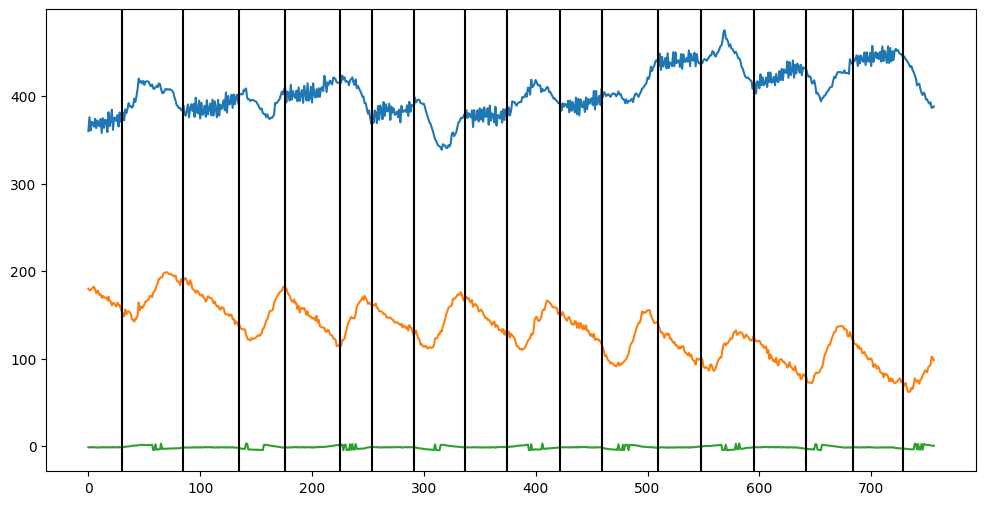

In [3]:
data = np.load(cfg.dataset)
samples = data["samples"]
gt_break_points = data["gt_break_points"]

plt.figure(figsize=(12, 6))
plt.plot(samples)
for bkp in gt_break_points:
    plt.axvline(bkp, color='k')

# Create Environent and Agent 

Initial Precision: 0.8889, Recall: 0.4706, F1: 0.6154


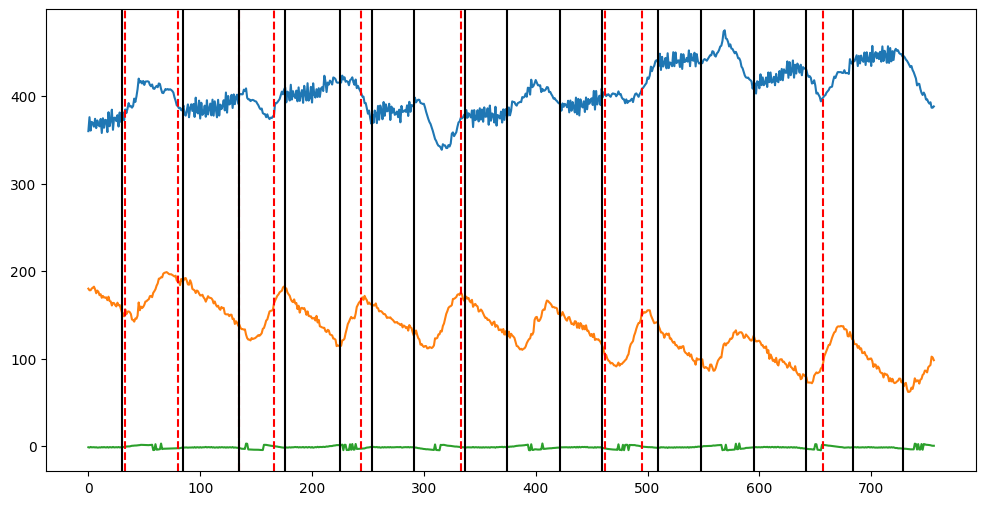

In [4]:
env = SegmentationEnv(
            samples=samples, 
            gt_break_points=gt_break_points,
            level_wavelet=cfg.level_wavelet,
            window_size=cfg.window_size,
            tolerance=cfg.tolerance,
            args=cfg) 

state, info = env.reset()
learner = DQNLearner(num_samples=samples.shape[0], gt_break_points=gt_break_points, args=cfg, options={"mode": 'eval'})


learner.model.load_state_dict(torch.load(cfg.checkpoint_root))

break_points = env.segmenter.get_break_points()

plt.figure(figsize=(12, 6))
plt.plot(samples)
for bkp in break_points:
    plt.axvline(bkp, color='r', linestyle='--')
for bkp in gt_break_points:
    plt.axvline(bkp, color='k')

print(f"Initial Precision: {info['precision']:.4f}, Recall: {info['recall']:.4f}, F1: {info['f1']:.4f}")

In [5]:
total_reward = 0
done = False
step = 0
while step < 31 and not done:
    action = learner.get_candidate(state)
    next_state, reward, done, terminated, info = env.step(action)
    total_reward += reward
    state = next_state
    step += 1
    print(f"Step Reward {step}: {reward:.4f}, Precision: {info['precision']:.4f}, Recall: {info['recall']:.4f}, F1: {info['f1']:.4f}")
    
print(f"Total Reward: {total_reward:.4f}")


Step Reward 1: 0.1009, Precision: 0.9000, Recall: 0.5294, F1: 0.6667
Step Reward 2: 0.0921, Precision: 0.9091, Recall: 0.5882, F1: 0.7143
Step Reward 3: 0.0842, Precision: 0.9167, Recall: 0.6471, F1: 0.7586
Step Reward 4: 0.1287, Precision: 1.0000, Recall: 0.7059, F1: 0.8276
Step Reward 5: 0.0000, Precision: 1.0000, Recall: 0.7059, F1: 0.8276
Step Reward 6: 0.0703, Precision: 1.0000, Recall: 0.7647, F1: 0.8667
Step Reward 7: -0.0494, Precision: 0.9286, Recall: 0.7647, F1: 0.8387
Step Reward 8: 0.0629, Precision: 0.9333, Recall: 0.8235, F1: 0.8750
Step Reward 9: 0.0000, Precision: 0.9333, Recall: 0.8235, F1: 0.8750
Step Reward 10: 0.0000, Precision: 0.9333, Recall: 0.8235, F1: 0.8750
Step Reward 11: -0.2625, Precision: 0.9091, Recall: 0.5882, F1: 0.7143
Step Reward 12: 0.1371, Precision: 0.9231, Recall: 0.7059, F1: 0.8000
Step Reward 13: 0.0000, Precision: 0.9231, Recall: 0.7059, F1: 0.8000
Step Reward 14: 0.0000, Precision: 0.9231, Recall: 0.7059, F1: 0.8000
Step Reward 15: 0.0000, Pre

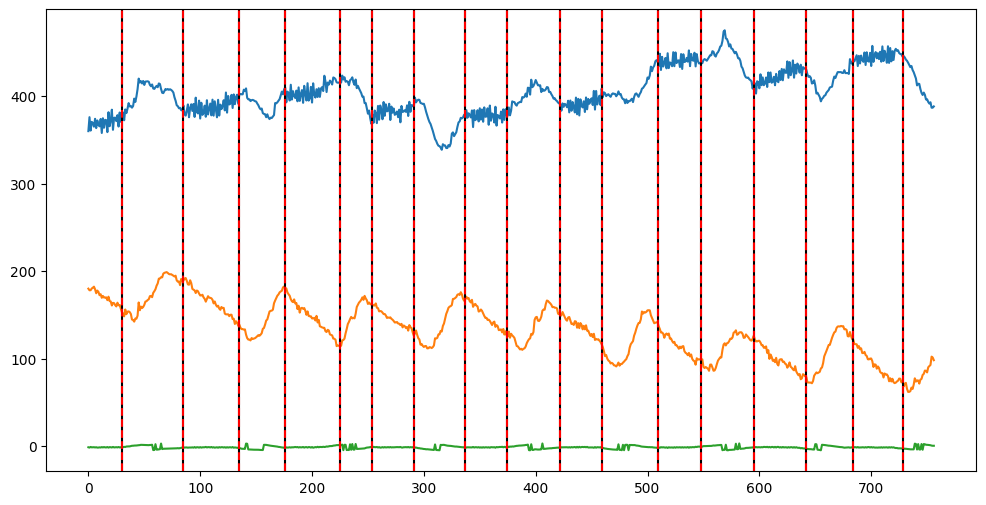

In [6]:
break_points = env.segmenter.get_break_points()

plt.figure(figsize=(12, 6))
plt.plot(samples)
for bkp in gt_break_points:
    plt.axvline(bkp, color='k')
for bkp in break_points:
    plt.axvline(bkp, color='r', linestyle='--')